In [15]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [16]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [18]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [20]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [22]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [23]:
# FT4_df.head()  # this would preview the robust scaled data
y = df.BMI  # use bmi1 as the target variable
x = df.drop('BMI', axis=1)  # use the other columns as features

In [24]:
y  # display the target column

,BMI
0,4
1,4
2,4
3,4
4,4
...,...
8497,1
8498,1
8499,1
8500,1


In [25]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,7,6,2,0,0,0,0,0,0,2,2,2,1,4,2,0,1,1
1,4,6,1,2,0,1,1,2,0,1,1,1,2,1,2,2,1,0
2,5,4,1,2,0,0,1,3,1,2,2,2,4,1,2,2,1,1
3,7,6,1,0,0,0,1,2,0,2,2,2,2,1,2,2,1,0
4,4,7,2,3,0,0,0,1,0,1,1,1,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,6,5,2,1,0,0,0,0,1,2,1,2,1,3,2,0,1,0
8498,6,3,1,0,0,0,1,0,0,1,1,1,3,3,1,1,1,1
8499,6,2,2,0,0,0,0,0,1,1,1,2,2,1,2,0,1,1
8500,4,7,2,1,1,0,1,1,1,2,2,1,2,2,2,0,0,1


In [26]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(5951, 18)

In [27]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(2551, 18)

In [28]:
# SMOTE in train data
y_train = LabelEncoder().fit_transform(y_train)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x_train, y_train = oversample.fit_resample(x_train, y_train)  # make class counts more balanced
counter = Counter(y_train)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y_train) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=2, count=3110, percentage=25.000%
class=1, count=3110, percentage=25.000%
class=3, count=3110, percentage=25.000%
class=0, count=3110, percentage=25.000%


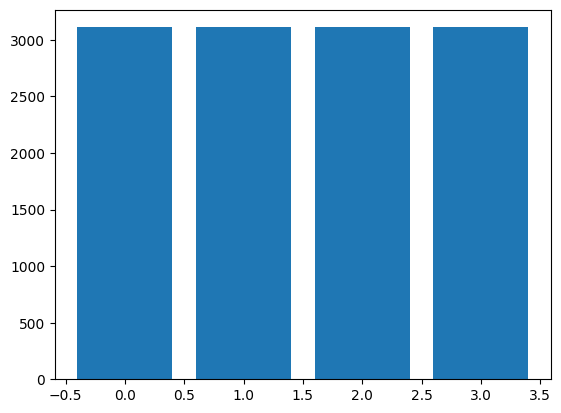

In [29]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [30]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.5090    0.6363    0.5656      3110
           1     0.4431    0.3994    0.4201      3110
           2     0.3952    0.2473    0.3042      3110
           3     0.4833    0.5910    0.5318      3110

    accuracy                         0.4685     12440
   macro avg     0.4576    0.4685    0.4554     12440
weighted avg     0.4576    0.4685    0.4554     12440

[[1979  551  174  406]
 [ 827 1242  521  520]
 [ 595  707  769 1039]
 [ 487  303  482 1838]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1022    0.3833    0.1614       240
           2     0.4512    0.1700    0.2469      1359
           3     0.3625    0.2742    0.3122       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2078      2551
   macro avg     0.1832    0.1655    0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores are [0.5440658  0.53701528 0.54705882 0.52       0.53529412 0.54
 0.54352941 0.52941176 0.54470588 0.54117647 0.54876616 0.53231492
 0.52705882 0.53647059 0.53529412 0.54470588 0.54235294 0.54823529
 0.55764706 0.52117647 0.53231492 0.54289072 0.53058824 0.54470588
 0.52941176 0.53294118 0.52941176 0.54941176 0.54823529 0.53882353]
Average Cross Validation score :0.5385004953802908


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0975    0.4208    0.1583       240
           2     0.4994    0.2936    0.3698      1359
           3     0.3693    0.1722    0.2349       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2470      2551
   macro avg     0.1932    0.1773    0.1526      2551
weighted avg     0.3845    0.2470    0.2814      2551

[[  0   0   0   0   0]
 [ 48 101  68  23   0]
 [218 586 399 156   0]
 [ 79 284 262 130   0]
 [ 19  65  70  43   0]]
Cross Validation Scores are [0.40893067 0.38777908 0.41529412 0.37294118 0.38470588 0.39411765
 0.39882353 0.4        0.38470588 0.38823529 0.40775558 0.37015276
 0.40588235 0.37647059 0.40117647 0.36823529 0.42470588 0.38823529
 0.38470588 0.36117647 0.41245593 0.39482961 0.35882353 0.39764706
 0.41411765 0.40235294 0.38823529 0.38941176 0.43294118 0.39647059]
Average Cross Validation score 

In [32]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1148    0.6250    0.1939       240
           2     0.4768    0.2568    0.3338      1359
           3     0.3680    0.1311    0.1934       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2344      2551
   macro avg     0.1919    0.2026    0.1442      2551
weighted avg     0.3737    0.2344    0.2533      2551

[[  0   0   0   0   0]
 [ 36 150  41  13   0]
 [152 734 349 124   0]
 [ 48 348 260  99   0]
 [  7  75  82  33   0]]
Cross Validation Scores are [0.50646298 0.50646298 0.52470588 0.5        0.51529412 0.51176471
 0.49882353 0.50705882 0.5        0.49882353 0.5052879  0.50058754
 0.53058824 0.50705882 0.51411765 0.50470588 0.51529412 0.51647059
 0.52235294 0.50235294 0.51821387 0.52056404 0.50588235 0.49647059
 0.50588235 0.48823529 0.47176471 0.50470588 0.51529412 0.51882353]
Average Cross Validation score 

In [33]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1048    0.3792    0.1643       240
           2     0.4556    0.2230    0.2994      1359
           3     0.3326    0.1894    0.2414       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2105      2551
   macro avg     0.1786    0.1583    0.1410      2551
weighted avg     0.3510    0.2105    0.2464      2551

[[  0   0   0   0   0]
 [ 83  91  42  24   0]
 [351 489 303 216   0]
 [129 247 236 143   0]
 [ 25  41  84  47   0]]
Cross Validation Scores are [0.47121034 0.48648649 0.48352941 0.44823529 0.49647059 0.48470588
 0.47058824 0.46470588 0.47529412 0.47882353 0.47003525 0.44770858
 0.50352941 0.46470588 0.50352941 0.47411765 0.47764706 0.47176471
 0.46705882 0.44588235 0.46768508 0.48766157 0.49176471 0.48352941
 0.48117647 0.46705882 0.43647059 0.46235294 0.48588235 0.49529412]
Average Cross Validation score 

In [34]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0940    0.2875    0.1417       240
           2     0.4786    0.1479    0.2260      1359
           3     0.3723    0.3629    0.3675       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2132      2551
   macro avg     0.1890    0.1597    0.1470      2551
weighted avg     0.3740    0.2132    0.2425      2551

[[  0   0   0   0   0]
 [108  69  21  42   0]
 [406 430 201 322   0]
 [129 198 154 274   0]
 [ 18  37  44  98   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.53231492 0.52056404 0.48941176 0.48352941 0.50470588 0.51529412
 0.51411765 0.50705882 0.48235294 0.48588235 0.50411281 0.51351351
 0.47882353 0.48352941 0.52352941 0.50941176 0.50941176 0.52352941
 0.51176471 0.48235294 0.49823737 0.50058754 0.48470588 0.52
 0.51411765 0.51529412 0.47411765 0.52470588 0.52470588 0.49647059]
Average Cross Validation score :0.5042717909725583


In [35]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1028    0.3792    0.1618       240
           2     0.4526    0.1089    0.1756      1359
           3     0.3737    0.3351    0.3534       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.1929      2551
   macro avg     0.1858    0.1646    0.1381      2551
weighted avg     0.3614    0.1929    0.2133      2551

[[  0   0   0   0   0]
 [ 97  91  15  37   0]
 [406 504 148 301   0]
 [139 243 120 253   0]
 [ 20  47  44  86   0]]
Cross Validation Scores are [0.5346651  0.5346651  0.54470588 0.52470588 0.53411765 0.53882353
 0.53294118 0.53176471 0.53764706 0.53529412 0.5440658  0.5346651
 0.52823529 0.53058824 0.53529412 0.54       0.53529412 0.54705882
 0.55058824 0.52117647 0.53113984 0.53936545 0.53647059 0.53882353
 0.53294118 0.53058824 0.52705882 0.53882353 0.54       0.54705882]
Average Cross Validation score :

In [36]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0929    0.2958    0.1414       240
           2     0.4761    0.2127    0.2940      1359
           3     0.3887    0.2914    0.3331       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2274      2551
   macro avg     0.1915    0.1600    0.1537      2551
weighted avg     0.3774    0.2274    0.2685      2551

[[  0   0   0   0   0]
 [106  71  38  25   0]
 [380 436 289 254   0]
 [115 214 206 220   0]
 [ 13  43  74  67   0]]
Cross Validation Scores are [0.52761457 0.55346651 0.54117647 0.52       0.52588235 0.52705882
 0.50941176 0.53294118 0.53411765 0.54       0.54759107 0.52761457
 0.51058824 0.53176471 0.52823529 0.54235294 0.54352941 0.55058824
 0.54941176 0.50705882 0.52761457 0.52878966 0.52823529 0.53529412
 0.51882353 0.52352941 0.52588235 0.53294118 0.54941176 0.54470588]
Average Cross Validation score 

In [37]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1067    0.4292    0.1710       240
           2     0.4659    0.2060    0.2857      1359
           3     0.3589    0.2358    0.2846       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2199      2551
   macro avg     0.1863    0.1742    0.1482      2551
weighted avg     0.3644    0.2199    0.2525      2551

[[  0   0   0   0   0]
 [ 85 103  31  21   0]
 [298 556 280 225   0]
 [ 99 255 223 178   0]
 [  7  51  67  72   0]]
Cross Validation Scores are [0.53701528 0.53349001 0.54823529 0.51294118 0.53411765 0.55529412
 0.52117647 0.54       0.52117647 0.53647059 0.54876616 0.52996475
 0.52117647 0.52352941 0.54470588 0.54352941 0.53176471 0.54117647
 0.56235294 0.51882353 0.54054054 0.5440658  0.51647059 0.53058824
 0.53882353 0.53176471 0.52235294 0.54705882 0.56352941 0.54235294]
Average Cross Validation score 

In [39]:
# XGBoost
from xgboost import XGBClassifier  # import XGBoost model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score # import evaluation tools
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score # import cross-validation tools
from sklearn.preprocessing import LabelEncoder

XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set

print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

cohen_kappa_score(y_test, predictions)  # calculate agreement score

# Encode y for cross-validation to match the training data encoding
y_encoded = LabelEncoder().fit_transform(y)
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y_encoded, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1170    0.5833    0.1949       240
           2     0.4878    0.2649    0.3433      1359
           3     0.3931    0.1656    0.2330       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2450      2551
   macro avg     0.1996    0.2028    0.1542      2551
weighted avg     0.3872    0.2450    0.2702      2551

[[  0   0   0   0   0]
 [ 44 140  41  15   0]
 [185 675 360 139   0]
 [ 61 314 255 125   0]
 [  8  68  82  39   0]]
Cross Validation Scores are [0.50176263 0.51233843 0.5        0.46823529 0.52823529 0.51411765
 0.48352941 0.47882353 0.47882353 0.46823529 0.46650999 0.48413631
 0.49764706 0.5        0.49529412 0.51294118 0.49176471 0.49411765
 0.52705882 0.46117647 0.50293772 0.48648649 0.47411765 0.49058824
 0.49882353 0.47647059 0.47294118 0.48705882 0.51176471 0.49647059]
Average Cross Validation score 

In [40]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1104    0.5667    0.1848       240
           2     0.4801    0.2487    0.3277      1359
           3     0.3716    0.1285    0.1909       755
           4     0.0000    0.0000    0.0000       197

    accuracy                         0.2238      2551
   macro avg     0.1924    0.1888    0.1407      2551
weighted avg     0.3762    0.2238    0.2485      2551

[[  0   0   0   0   0]
 [ 52 136  39  13   0]
 [213 691 338 117   0]
 [ 78 329 251  97   0]
 [ 11  76  76  34   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.47356052 0.48648649 0.46352941 0.46352941 0.47411765 0.48117647
 0.46       0.47294118 0.43882353 0.46588235 0.43948296 0.47591069
 0.48823529 0.45882353 0.48823529 0.44588235 0.48588235 0.47058824
 0.47058824 0.45764706 0.47238543 0.49353702 0.48470588 0.49058824
 0.47529412 0.45411765 0.46       0.45176471 0.45764706 0.48117647]
Average Cross Validation score :0.4694179857606967
